In [11]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import snntorch as snn
import snntorch.spikegen as spikegen


df = pd.read_csv("final_data.csv")



In [12]:
df['Flow_delta'] = df['Flow_L_min'].diff()

In [13]:
df['Flow_delta'] = df['Flow_delta'].fillna(0)

In [14]:
df['Flow_low'] = (df['Flow_L_min'] < 0.2).astype(int)

In [15]:
df['Flow_ratio'] = df['Flow_L_min'] / (df['Turbidity_smooth'] + 1)

In [16]:
df

,Flow_L_min,label,TDS_smooth,Turbidity_smooth,Flow_delta,Flow_low,Flow_ratio
0,0.27,2,825.6,2532.2,0.00,0,0.000107
1,0.53,1,1229.0,3100.2,0.26,0,0.000171
2,0.27,2,899.0,3121.0,-0.26,0,0.000086
3,0.27,2,816.6,2424.0,0.00,0,0.000111
4,1.33,0,934.2,1662.2,1.06,0,0.000800
...,...,...,...,...,...,...,...
3540,0.27,2,811.0,2393.0,0.14,0,0.000113
3541,0.27,2,979.0,2426.8,0.00,0,0.000111
3542,1.33,0,979.8,1738.6,1.06,0,0.000765
3543,0.27,2,1030.4,2704.0,-1.06,0,0.000100


In [41]:




X = df[['TDS_smooth','Turbidity_smooth','Flow_L_min','Flow_delta','Flow_low',"Flow_ratio"]]
y = df['label']



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)


scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values)
y_test = torch.tensor(y_test.values)

# -----------------------------
# DataLoader
# -----------------------------
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# -----------------------------
# SNN Parameters
# -----------------------------
num_inputs = 6
num_hidden = 20
num_outputs = 4
num_steps = 40

# -----------------------------
# SNN Model
# -----------------------------
class Net(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=0.9)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=0.9)

    def forward(self, x):

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []

        for step in range(x.size(0)):

            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)

        return torch.stack(spk2_rec)

# -----------------------------
# Initialize Model
# -----------------------------
model = Net()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# -----------------------------
# Training
# -----------------------------
epochs = 50

for epoch in range(epochs):

    total_loss = 0

    for data, targets in train_loader:

        spikes = spikegen.rate(data, num_steps=num_steps)

        optimizer.zero_grad()

        spk_out = model(spikes)

        loss = loss_fn(spk_out.sum(0), targets)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss: {total_loss:.4f}")

# -----------------------------
# Testing
# -----------------------------
with torch.no_grad():

    test_spikes = spikegen.rate(X_test, num_steps=num_steps)

    test_spk = model(test_spikes)

    _, predicted = test_spk.sum(0).max(1)

    accuracy = (predicted == y_test).float().mean()

    print("Accuracy:", accuracy.item())

Epoch 0 Loss: 44.6778
Epoch 1 Loss: 27.9366
Epoch 2 Loss: 22.2156
Epoch 3 Loss: 20.1799
Epoch 4 Loss: 18.8688
Epoch 5 Loss: 18.1313
Epoch 6 Loss: 18.0224
Epoch 7 Loss: 18.8605
Epoch 8 Loss: 17.1929
Epoch 9 Loss: 18.0197
Epoch 10 Loss: 16.2169
Epoch 11 Loss: 17.5712
Epoch 12 Loss: 16.7199
Epoch 13 Loss: 18.3113
Epoch 14 Loss: 17.7751
Epoch 15 Loss: 17.0005
Epoch 16 Loss: 18.2673
Epoch 17 Loss: 16.9738
Epoch 18 Loss: 16.1759
Epoch 19 Loss: 16.8079
Epoch 20 Loss: 15.8858
Epoch 21 Loss: 16.3952
Epoch 22 Loss: 16.2444
Epoch 23 Loss: 15.4372
Epoch 24 Loss: 16.2334
Epoch 25 Loss: 15.5187
Epoch 26 Loss: 14.7304
Epoch 27 Loss: 16.2983
Epoch 28 Loss: 17.8768
Epoch 29 Loss: 16.8107
Epoch 30 Loss: 16.7525
Epoch 31 Loss: 15.2803
Epoch 32 Loss: 14.3790
Epoch 33 Loss: 15.2815
Epoch 34 Loss: 15.9708
Epoch 35 Loss: 15.4322
Epoch 36 Loss: 15.5083
Epoch 37 Loss: 15.9693
Epoch 38 Loss: 15.2143
Epoch 39 Loss: 16.3856
Epoch 40 Loss: 14.6559
Epoch 41 Loss: 15.2454
Epoch 42 Loss: 15.8005
Epoch 43 Loss: 15.287


Classification Report

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       188
           1       0.89      0.91      0.90       221
           2       0.80      0.78      0.79       175
           3       0.80      0.75      0.77       125

    accuracy                           0.86       709
   macro avg       0.85      0.85      0.85       709
weighted avg       0.86      0.86      0.86       709



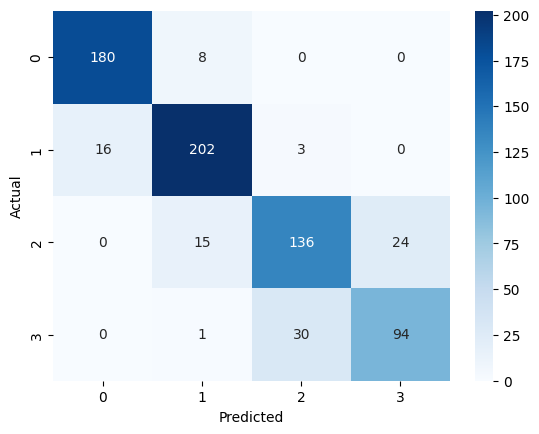

ROC-AUC: 0.8787581750841189


In [42]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

print("\nClassification Report\n")
print(classification_report(y_test, predicted))

cm = confusion_matrix(y_test, predicted)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

scores = test_spk.sum(0)

y_bin = label_binarize(y_test, classes=[0,1,2,3])

roc = roc_auc_score(y_bin, scores.numpy(), multi_class="ovr")

print("ROC-AUC:", roc)

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, predicted, average=None)
recall = recall_score(y_test, predicted, average=None)
f1 = f1_score(y_test, predicted, average=None)

labels = ["Normal", "Soap", "Mud", "Blockage"]

for i in range(4):
    print(labels[i])
    print("Precision:", precision[i])
    print("Recall:", recall[i])
    print("F1:", f1[i])
    print()

Normal
Precision: 0.9183673469387755
Recall: 0.9574468085106383
F1: 0.9375

Soap
Precision: 0.8938053097345132
Recall: 0.9140271493212669
F1: 0.9038031319910514

Mud
Precision: 0.8047337278106509
Recall: 0.7771428571428571
F1: 0.7906976744186046

Blockage
Precision: 0.7966101694915254
Recall: 0.752
F1: 0.7736625514403292



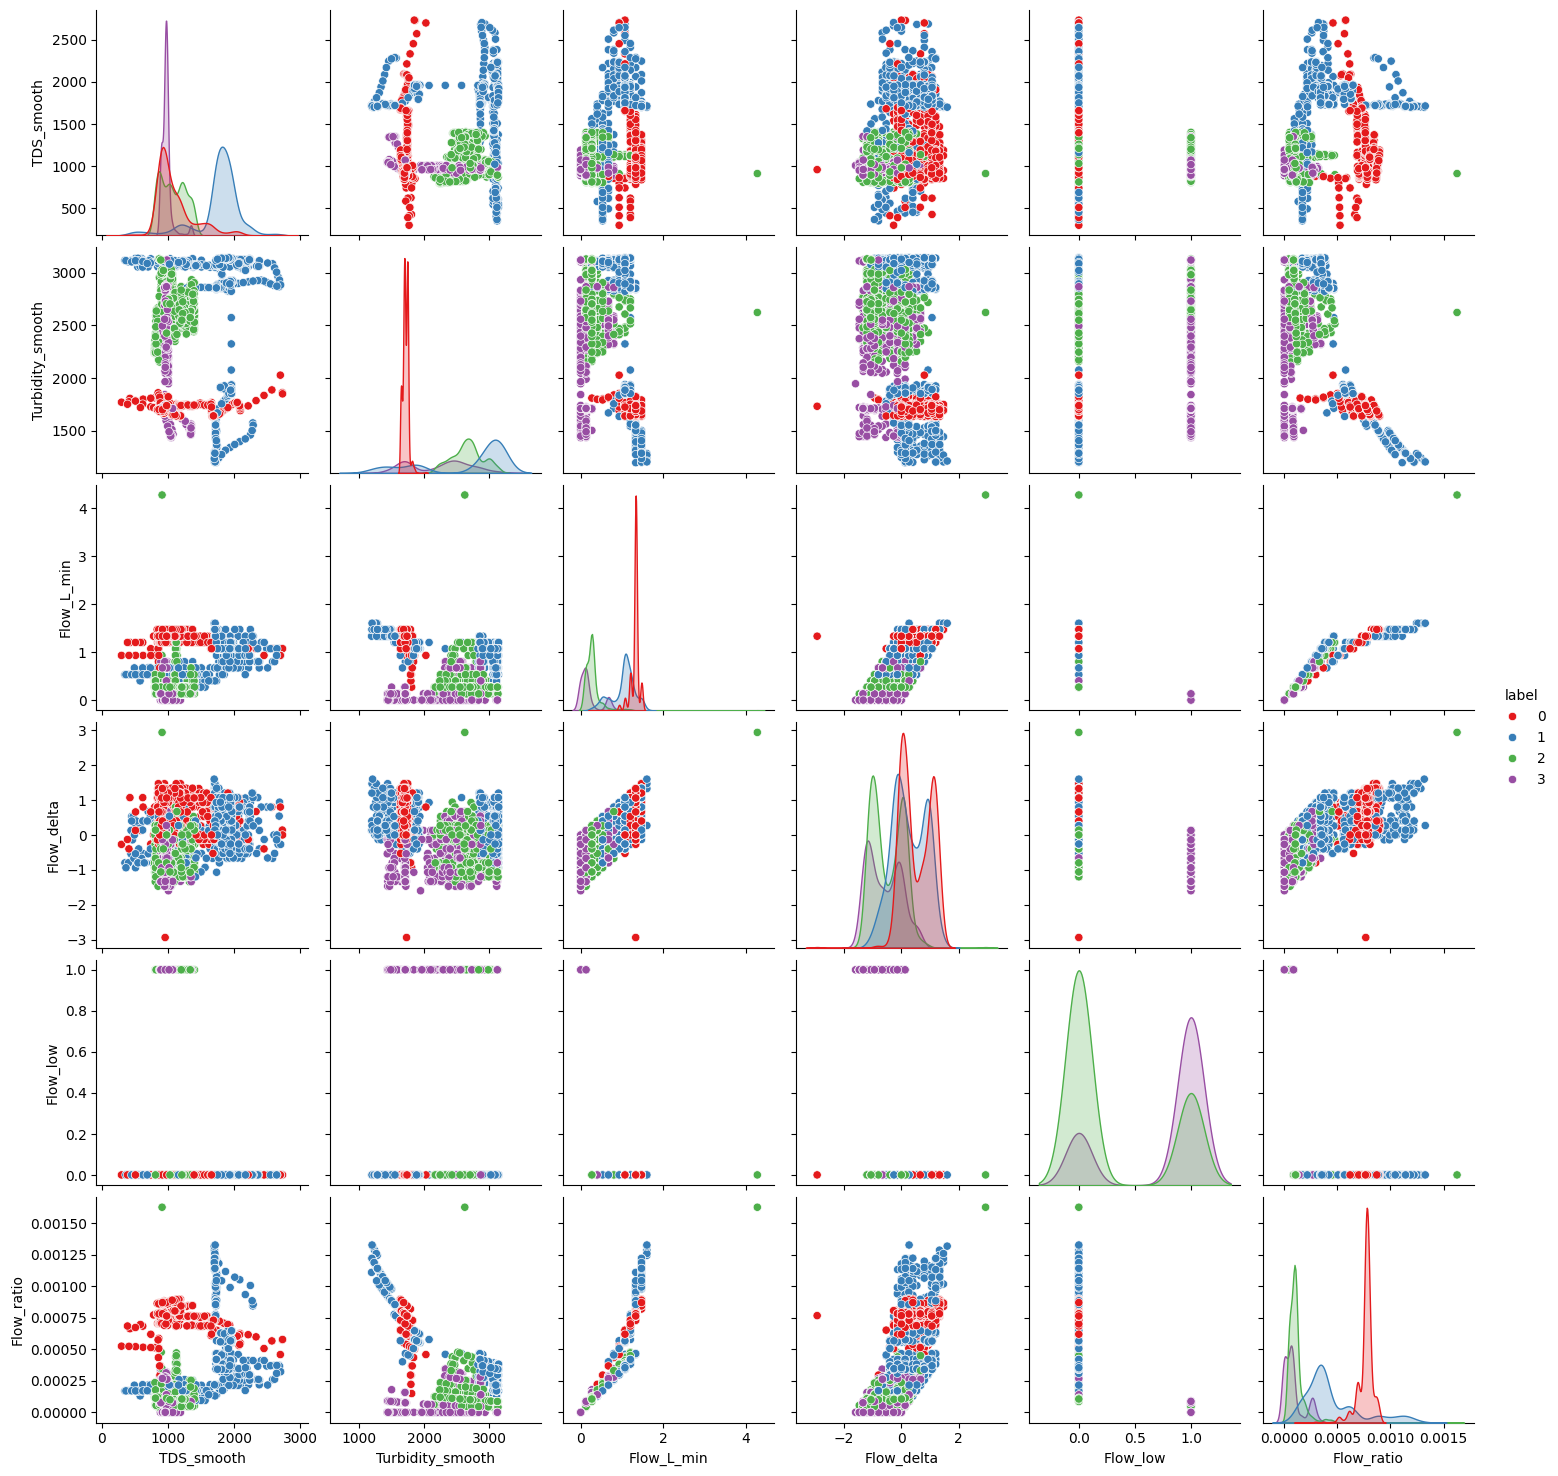

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.pairplot(
    df,
    vars=df[['TDS_smooth','Turbidity_smooth','Flow_L_min','Flow_delta','Flow_low',"Flow_ratio"]],
    hue='label',
    palette='Set1'
)

plt.show()

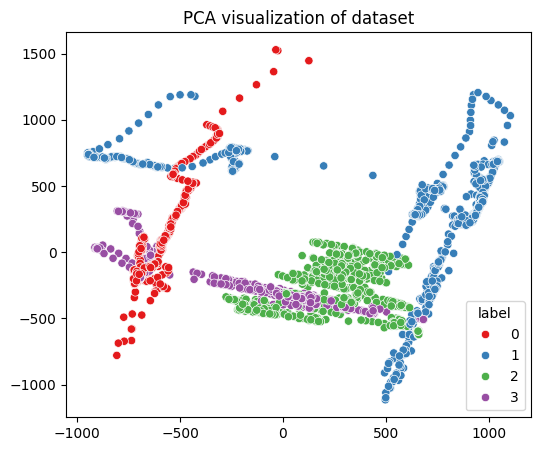

In [21]:
from sklearn.decomposition import PCA

X = df[['TDS_smooth','Turbidity_smooth','Flow_L_min','Flow_delta','Flow_low',"Flow_ratio"]]
y = df['label']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="Set1")
plt.title("PCA visualization of dataset")
plt.show()

In [22]:


# import pandas as pd
# import numpy as np

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.utils.class_weight import compute_class_weight
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Input
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# # Load dataset
# df = pd.read_csv('final_data.csv')

# # Features and target
# X = df[['Flow_L_min', 'TDS_smooth', 'Turbidity_smooth']].values
# y = df['label'].values

# # Encode target labels
# le = LabelEncoder()
# y = le.fit_transform(y)

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # Scale features
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# # Number of classes
# num_classes = len(np.unique(y))

# # Class weights
# classes = np.unique(y)
# class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
# class_weight_dict = dict(enumerate(class_weights))

# # Build improved ANN
# model = Sequential([
#     Input(shape=(3,)),
#     Dense(16, activation='relu'),
#     Dense(8, activation='relu'),
#     Dense(num_classes, activation='softmax')
# ])

# # Compile
# model.compile(
#     optimizer=Adam(learning_rate=0.001),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# # Early stopping
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=10,
#     restore_best_weights=True
# )

# # Train
# history = model.fit(
#     X_train, y_train,
#     epochs=100,
#     batch_size=16,
#     validation_split=0.2,
#     callbacks=[early_stop],
#     class_weight=class_weight_dict,
#     verbose=1
# )

# from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# # Evaluate model
# loss, accuracy = model.evaluate(X_test, y_test)
# print("Test Loss:", loss)
# print("Test Accuracy:", accuracy)

# # Predict
# predictions = model.predict(X_test)
# predicted_classes = np.argmax(predictions, axis=1)

# print("First 10 predicted classes:", predicted_classes[:10])
# print("First 10 actual classes:   ", y_test[:10])

# # Precision, Recall, F1
# precision = precision_score(y_test, predicted_classes, average='weighted')
# recall = recall_score(y_test, predicted_classes, average='weighted')
# f1 = f1_score(y_test, predicted_classes, average='weighted')

# print("\nPrecision:", precision)
# print("Recall:", recall)
# print("F1 Score:", f1)

# # Classification report
# print("\nClassification Report:\n")
# print(classification_report(
#     y_test,
#     predicted_classes,
#     target_names=[str(c) for c in le.classes_]
# ))

# from sklearn.preprocessing import label_binarize
# from sklearn.metrics import roc_curve, auc, roc_auc_score
# import matplotlib.pyplot as plt

# # Get predicted probabilities from model
# y_score = model.predict(X_test)

# # Binarize the true labels for multiclass ROC
# classes = np.unique(y_test)
# y_test_bin = label_binarize(y_test, classes=classes)

# # Plot ROC curve for each class
# plt.figure(figsize=(8, 6))

# for i in range(len(classes)):
#     fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
#     roc_auc = auc(fpr, tpr)
#     plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

# # Diagonal line for random classifier
# plt.plot([0, 1], [0, 1], linestyle='--')

# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve for Multiclass ANN')
# plt.legend(loc='lower right')
# plt.grid(True)
# plt.show()

# # Overall ROC-AUC score
# roc_auc_ovr = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
# print("Overall ROC-AUC Score (OvR):", roc_auc_ovr)


# from sklearn.model_selection import cross_val_score
# from sklearn.neural_network import MLPClassifier

# model = MLPClassifier(hidden_layer_sizes=(16,8))
# scores = cross_val_score(model, X, y, cv=5)

# print(scores)
# print("Mean accuracy:", scores.mean())